In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from main.utils import load_json, save_to_json

In [5]:
text = load_json(r'D:\Git_repo\ViSoMMSD\data\silver\silver_text.json')
image = load_json(r'D:\Git_repo\ViSoMMSD\data\silver\silver_image.json')
multi = load_json(r'D:\Git_repo\ViSoMMSD\data\silver\silver_multi.json')

In [6]:
all =[]

for i in range(len(multi)):
    all.append(
        {
        "caption": multi[i]['caption'],
        "image": multi[i]['image'],
        "text_modality": text[i]['label'],
        "image_modality": image[i]['label'],
        "multi_modality": multi[i]['label']


        }
    )

In [7]:
all

[{'caption': 'PSG chính thức vô địch Ligue 1 sớm 6 vòng đấu',
  'image': 'fb_355.jpg',
  'text_modality': 'non-sarcasm',
  'image_modality': 'sarcasm',
  'multi_modality': 'non-sarcasm'},
 {'caption': 'Ham hố lắm í =)))))',
  'image': 'fb_1722.jpg',
  'text_modality': 'sarcasm',
  'image_modality': 'non-sarcasm',
  'multi_modality': 'sarcasm'},
 {'caption': 'Sao biết vậy',
  'image': 'fb_2589.jpg',
  'text_modality': 'non-sarcasm',
  'image_modality': 'sarcasm',
  'multi_modality': 'non-sarcasm'},
 {'caption': 'Nhà ngta “bày” cỡ đó, nhà t “bay” cỡ này, coi ngang ngược hong',
  'image': 'fb_6064.jpg',
  'text_modality': 'sarcasm',
  'image_modality': 'sarcasm',
  'multi_modality': 'sarcasm'},
 {'caption': 'Tiên trách kỉ, hậu trách nhân',
  'image': 'fb_2957.jpg',
  'text_modality': 'non-sarcasm',
  'image_modality': 'sarcasm',
  'multi_modality': 'non-sarcasm'},
 {'caption': '- kachiusa -',
  'image': 'fb_3717.jpg',
  'text_modality': 'non-sarcasm',
  'image_modality': 'sarcasm',
  'mul

In [9]:
save_to_json(all, 'all.json')

In [ ]:
all = [
    {
        "caption": multi['caption'],
        "image": multi['image'],
        "text_modality": text[]
    }
]

In [61]:
# Đọc dữ liệu
with open(r"D:\Git_repo\ViSoMMSD\data\gold\1k_gold.json", "r", encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame(data)



In [62]:
# 1. Độ dài caption
df['caption_length'] = df['caption'].apply(lambda x: len(str(x).split()))
length_stats = {
    "mean": df['caption_length'].mean(),
    "min": df['caption_length'].min(),
    "max": df['caption_length'].max(),
    "le5": (df['caption_length'] <= 5).sum(),
    "ge100": (df['caption_length'] >= 100).sum(),
}



In [55]:
plt.rcParams['font.family'] = 'DejaVu Sans'  # Có sẵn trên đa số môi trường, hợp tiếng Việt
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.labelweight'] = 'semibold'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

sns.set_style("whitegrid")  # style nền sáng, lưới nhẹ
sns.set_palette("Set2")     # palette màu nhẹ, đẹp

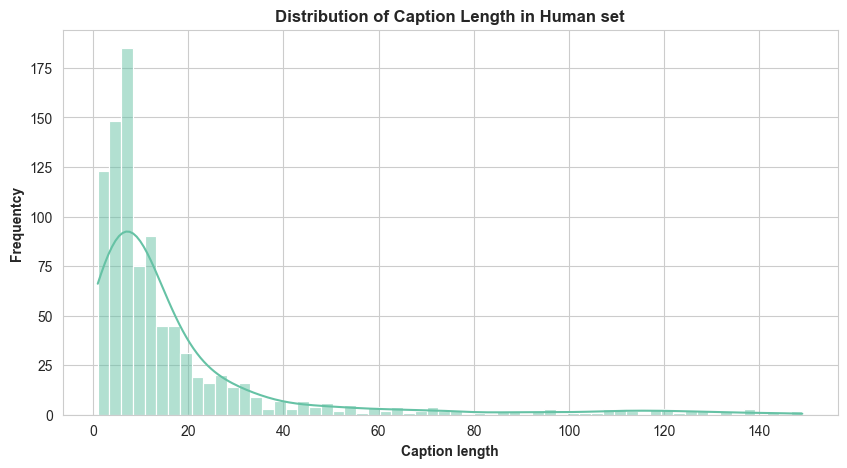

In [63]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['caption_length']<150]['caption_length'], bins=60, kde=True)
plt.title("Distribution of Caption Length in Human set")
plt.xlabel("Caption length")
plt.ylabel("Frequentcy")
plt.show()


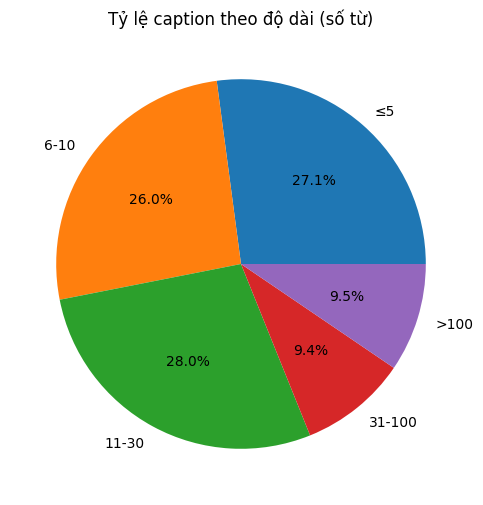

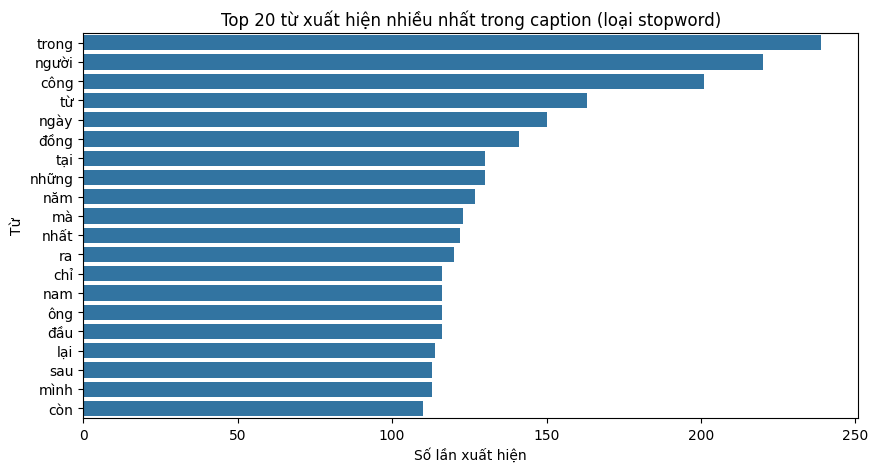

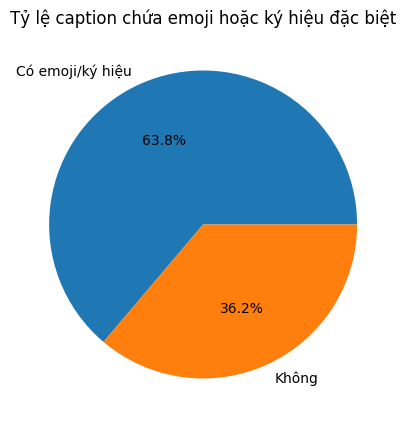

Thống kê độ dài caption: {'mean': 37.309, 'min': 1, 'max': 1540, 'le5': 271, 'ge100': 95}
Top caption trùng lặp nhiều nhất: caption
?                                                                                                                                                                                                            4
???                                                                                                                                                                                                          2
- 2B                                                                                                                                                                                                         2
Thân chưa mà giỡn kiểu đó =))))) ảnh: P Khanh Chi                                                                                                                                                            2
Chiều qua (21/4), cụ Thanh đã nghỉ ngơi 

In [9]:
# 3. Top 10 caption trùng lặp nhiều nhất
top_dupes = df['caption'].value_counts().head(10)

# 4. Pie chart các caption ngắn nhất/dài nhất
length_bins = pd.cut(df['caption_length'], bins=[0,5,10,30,100,2000], 
                     labels=["≤5","6-10","11-30","31-100",">100"])
length_bins_count = length_bins.value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(length_bins_count, labels=length_bins_count.index, autopct="%1.1f%%")
plt.title("Tỷ lệ caption theo độ dài (số từ)")
plt.show()

# 5. Caption chứa emoji hoặc ký hiệu đặc biệt
emoji_pattern = r"[=:\-\(\)<3v\)]+"
df['has_emoji'] = df['caption'].apply(lambda x: bool(re.search(emoji_pattern, x)))
emoji_count = df['has_emoji'].sum()

# 6. Top 20 từ xuất hiện nhiều nhất (sau khi tách từ, loại bỏ stopwords cơ bản)
from collections import Counter
import string

def basic_tokenizer(text):
    text = text.lower()
    for ch in string.punctuation:
        text = text.replace(ch, " ")
    return text.split()

stopwords = set([
    'là', 'của', 'và', 'có', 'cho', 'trên', 'này', 'một', 'được', 'không', 'với', 'các', 'thì', 'tôi', 'bạn', 
    'em', 'anh', 'chị', 'ở', 'đã', 'sẽ', 'về', 'khi', 'đang', 'làm', 'như', 'nên', 'đi', 'vì', 'nhưng', 'đến', 'để'
])

words = []
for caption in df['caption']:
    tokens = basic_tokenizer(str(caption))
    words.extend([w for w in tokens if w not in stopwords and len(w)>1])
top_words = Counter(words).most_common(20)

# 7. Trực quan hóa top từ xuất hiện nhiều nhất
top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])
plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=top_words_df)
plt.title("Top 20 từ xuất hiện nhiều nhất trong caption (loại stopword)")
plt.xlabel("Số lần xuất hiện")
plt.ylabel("Từ")
plt.show()

# 8. Tỉ lệ caption chứa emoji
plt.figure(figsize=(5,5))
plt.pie([emoji_count, len(df)-emoji_count], labels=["Có emoji/ký hiệu", "Không"], autopct="%1.1f%%")
plt.title("Tỷ lệ caption chứa emoji hoặc ký hiệu đặc biệt")
plt.show()

# 9. Caption đặc biệt (1-2 từ, dài nhất, caption lặp nhiều nhất)
shortest = df[df['caption_length'] == df['caption_length'].min()]['caption'].tolist()
longest = df[df['caption_length'] == df['caption_length'].max()]['caption'].tolist()
most_duplicated = top_dupes.index.tolist()

# Xuất một số thống kê
print("Thống kê độ dài caption:", length_stats)
print("Top caption trùng lặp nhiều nhất:", top_dupes)
print("Số caption chứa emoji/ký hiệu đặc biệt:", emoji_count)
print("Một số caption ngắn nhất:", shortest[:5])
print("Một số caption dài nhất:", longest[:1])
print("Caption lặp lại nhiều:", most_duplicated[:5])
print("Top 20 từ xuất hiện nhiều nhất:", top_words)


In [64]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Giả sử ảnh nằm trong thư mục /mnt/data/images/
img_folder = r'D:\Git_repo\ViSoMMSD\data\images'

# Đọc tên ảnh từ dataframe (giả định đã có cột df['image'])
aspect_ratios = []
not_found = 0
for img_file in df['image']:
    img_path = os.path.join(img_folder, img_file)
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            if h > 0:
                aspect = round(w / h, 2)  # làm tròn cho histogram mịn hơn
                aspect_ratios.append(aspect)
    except Exception as e:
        not_found += 1



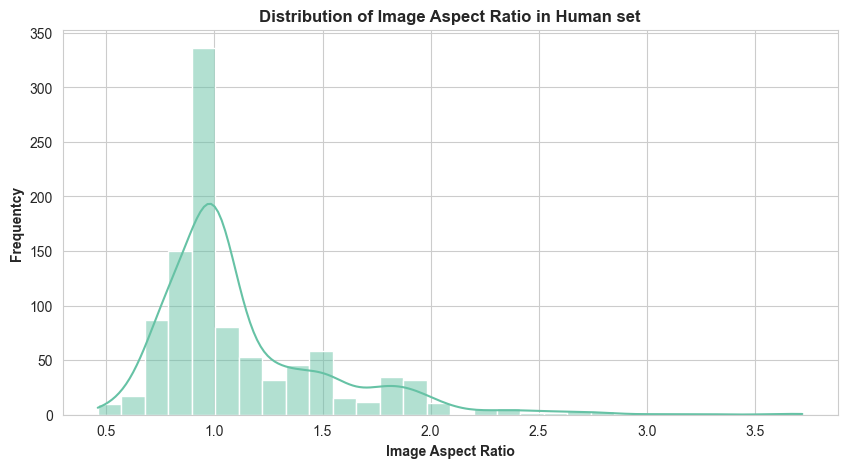

Số ảnh không tìm thấy hoặc lỗi đọc: 0


In [65]:

# Vẽ histogram
plt.figure(figsize=(10,5))
sns.histplot(aspect_ratios, bins=30, kde=True)
plt.title("Distribution of Image Aspect Ratio in Human set")
plt.xlabel("Image Aspect Ratio")
plt.ylabel("Frequentcy")
plt.show()

print(f"Số ảnh không tìm thấy hoặc lỗi đọc: {not_found}")